# Ecommerce Product Category Classification
## 1. Data Acquisition and Cleaning

**TechCrush AI/ML Bootcamp — Cohort 5 Capstone Project**

---

### 1.1 Project Overview

This project addresses the problem of **automatic product category classification** in ecommerce. Given a product image, our deep learning model will predict which of 54 article types (e.g., Tshirts, Watches, Casual Shoes) the product belongs to.

This is a real-world problem — platforms like Jumia, Amazon, and Konga deal with millions of product listings. Manual categorisation is slow and error-prone. An automated classifier saves time, improves consistency, and scales effortlessly.

### 1.2 Dataset Source

**Dataset:** Fashion Product Images Dataset  
**Source:** Kaggle — https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-dataset  
**License:** Open for educational and research use  

The dataset contains **44,441 product images** from the Indian fashion ecommerce platform Myntra, along with a metadata CSV file (`styles.csv`) describing each product.

### 1.3 Dataset Description

The metadata file (`styles.csv`) has **44,424 rows and 10 columns**:

| Column | Description |
|---|---|
| `id` | Unique product ID — links to image filename (e.g., 15970.jpg) |
| `gender` | Target gender: Men, Women, Boys, Girls, Unisex |
| `masterCategory` | Broad category: Apparel, Footwear, Accessories, etc. |
| `subCategory` | Mid-level category: Topwear, Shoes, Bags, etc. |
| `articleType` | **Target variable** — specific product type: Tshirts, Watches, etc. |
| `baseColour` | Dominant colour of the product |
| `season` | Season the product is suited for |
| `year` | Year the product was listed |
| `usage` | Occasion: Casual, Formal, Sports, etc. |
| `productDisplayName` | Full product title as shown on the platform |

**Target variable:** `articleType` (143 unique classes in raw data, filtered to 54 after cleaning)

---

In [1]:
import tensorflow as tf

print("TensorFlow Version:", tf.__version__)
print("GPUs Available:", len(tf.config.list_physical_devices('GPU')))

2026-06-04 10:58:30.926294: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780570711.179867      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780570711.249594      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780570711.838023      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780570711.838060      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780570711.838062      58 computation_placer.cc:177] computation placer alr

TensorFlow Version: 2.19.0
GPUs Available: 2


## Step 1 — Mount Google Drive and Set Paths

We mount Google Drive to access our dataset. The dataset folder was uploaded to our Google Drive before mounting the drive.

In [18]:
import os
import pandas as pd

DATASET_PATH = "/kaggle/input/datasets/efeataminyo/ecommerce-products/archive (2)/myntradataset"

CSV_PATH = os.path.join(DATASET_PATH, "styles.csv")
IMAGES_PATH = os.path.join(DATASET_PATH, "images")

print(CSV_PATH)
print(IMAGES_PATH)

/kaggle/input/datasets/efeataminyo/ecommerce-products/archive (2)/myntradataset/styles.csv
/kaggle/input/datasets/efeataminyo/ecommerce-products/archive (2)/myntradataset/images


In [3]:
from google.colab import drive
drive.mount('/content/drive')

!unzip "/content/drive/MyDrive/archive (4).zip"

Streaming output truncated to the last 5000 lines.
  inflating: archive (2)/myntradataset/images/5813.jpg  
  inflating: archive (2)/myntradataset/images/58131.jpg  
  inflating: archive (2)/myntradataset/images/58132.jpg  
  inflating: archive (2)/myntradataset/images/58133.jpg  
  inflating: archive (2)/myntradataset/images/58135.jpg  
  inflating: archive (2)/myntradataset/images/58136.jpg  
  inflating: archive (2)/myntradataset/images/58137.jpg  
  inflating: archive (2)/myntradataset/images/58138.jpg  
  inflating: archive (2)/myntradataset/images/58139.jpg  
  inflating: archive (2)/myntradataset/images/5814.jpg  
  inflating: archive (2)/myntradataset/images/58140.jpg  
  inflating: archive (2)/myntradataset/images/58141.jpg  
  inflating: archive (2)/myntradataset/images/58143.jpg  
  inflating: archive (2)/myntradataset/images/58144.jpg  
  inflating: archive (2)/myntradataset/images/58145.jpg  
  inflating: archive (2)/myntradataset/images/58146.jpg  
  inflating: archive (2

## Step 2 — Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Assisted by Claude AI — standard library imports adapted for this dataset
print('All libraries imported successfully.')

All libraries imported successfully.


## Step 3 — Load the Dataset

We use `on_bad_lines='skip'` because the CSV contains a small number of malformed rows (lines where commas inside text fields break the parser). Skipping them is safer than crashing, and we will account for any row loss in our cleaning report.

In [19]:
# Load the metadata CSV
# Assisted by Claude AI — on_bad_lines='skip' handles malformed rows in this dataset
df = pd.read_csv(CSV_PATH, on_bad_lines='skip')

print('Dataset loaded successfully.')
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print()
df.head(10)

Dataset loaded successfully.
Shape: 44,424 rows × 10 columns



,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt
5,1855,Men,Apparel,Topwear,Tshirts,Grey,Summer,2011.0,Casual,Inkfruit Mens Chain Reaction T-shirt
6,30805,Men,Apparel,Topwear,Shirts,Green,Summer,2012.0,Ethnic,Fabindia Men Striped Green Shirt
7,26960,Women,Apparel,Topwear,Shirts,Purple,Summer,2012.0,Casual,Jealous 21 Women Purple Shirt
8,29114,Men,Accessories,Socks,Socks,Navy Blue,Summer,2012.0,Casual,Puma Men Pack of 3 Socks
9,30039,Men,Accessories,Watches,Watches,Black,Winter,2016.0,Casual,Skagen Men Black Watch


## Step 4 — Initial Inspection

Before cleaning, we inspected the dataset to understand what we are working with. That is understanding the data types, basic statistics, and a first look at missing values.

In [20]:
# Column data types
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44424 entries, 0 to 44423
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  44424 non-null  int64  
 1   gender              44424 non-null  object 
 2   masterCategory      44424 non-null  object 
 3   subCategory         44424 non-null  object 
 4   articleType         44424 non-null  object 
 5   baseColour          44409 non-null  object 
 6   season              44403 non-null  object 
 7   year                44423 non-null  float64
 8   usage               44107 non-null  object 
 9   productDisplayName  44417 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 3.4+ MB


,id,year
count,44424.000000,44423.000000
mean,29696.334301,2012.806497
std,17049.490518,2.126480
min,1163.000000,2007.000000
25%,14768.750000,2011.000000
50%,28618.500000,2012.000000
75%,44683.250000,2015.000000
max,60000.000000,2019.000000


In [21]:
# Check unique values in categorical columns
cat_cols = ['gender', 'masterCategory', 'subCategory', 'articleType',
            'baseColour', 'season', 'usage']

print('Unique value counts per categorical column:')
print('=' * 40)
for col in cat_cols:
    print(f'{col:25s}: {df[col].nunique()} unique values')

Unique value counts per categorical column:
gender                   : 5 unique values
masterCategory           : 7 unique values
subCategory              : 45 unique values
articleType              : 143 unique values
baseColour               : 46 unique values
season                   : 4 unique values
usage                    : 8 unique values


## Step 5 — Check for Duplicate Rows

Duplicate rows can bias a model by making it see the same sample multiple times during training. We identified and removed them.

In [22]:
duplicates = df.duplicated().sum()
print(f'Number of duplicate rows: {duplicates}')

if duplicates > 0:
    df = df.drop_duplicates()
    print(f'Duplicates removed. New shape: {df.shape}')
else:
    print('No duplicates found. No action needed.')

Number of duplicate rows: 0
No duplicates found. No action needed.


## Step 6 — Check for Missing Values

Missing values need to be addressed before modelling. We inspect each column and decide on a case-by-case basis whether to fill or drop.

In [23]:
# Count and percentage of missing values per column
missing_count = df.isnull().sum()
missing_pct   = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %': missing_pct
})

print('Missing Values Summary:')
print('=' * 40)
print(missing_df[missing_df['Missing Count'] > 0])

Missing Values Summary:
                    Missing Count  Missing %
baseColour                     15       0.03
season                         21       0.05
year                            1       0.00
usage                         317       0.71
productDisplayName              7       0.02


### Missing Value Decisions

| Column | Missing | % | Decision | Reason |
|---|---|---|---|---|
| `usage` | 317 | ~0.7% | Fill with `'Unknown'` | Usage is not our target; losing 317 rows is unnecessary |
| `baseColour` | 15 | ~0.03% | Fill with `'Unknown'` | Very small number; dropping would be wasteful |
| `season` | 21 | ~0.05% | Fill with `'Unknown'` | Very small number; filling preserves rows |
| `productDisplayName` | 7 | ~0.02% | Fill with `'Unknown'` | Not our primary feature; safe to fill |
| `year` | 1 | ~0.002% | Fill with mode (most common year) | Only one row missing; filling with mode is appropriate |

**Note:** `id`, `gender`, `masterCategory`, `subCategory`, and `articleType` have zero missing values — no action needed for these.

In [24]:
# Assisted by Claude AI — filling strategy adapted for this specific dataset

# Fill categorical columns with 'Unknown'
df['usage']              = df['usage'].fillna('Unknown')
df['baseColour']         = df['baseColour'].fillna('Unknown')
df['season']             = df['season'].fillna('Unknown')
df['productDisplayName'] = df['productDisplayName'].fillna('Unknown')

# Fill year with the mode (most frequent year)
year_mode = df['year'].mode()[0]
df['year'] = df['year'].fillna(year_mode)
df['year'] = df['year'].astype(int)
print(f'Year missing value filled with mode: {int(year_mode)}')

# Confirm no missing values remain
print()
print('Missing values after cleaning:')
print(df.isnull().sum())

Year missing value filled with mode: 2012

Missing values after cleaning:
id                    0
gender                0
masterCategory        0
subCategory           0
articleType           0
baseColour            0
season                0
year                  0
usage                 0
productDisplayName    0
dtype: int64


## Step 7 — Check and Fix Data Types

We ensure each column is stored as the correct data type. Incorrect types can cause errors during preprocessing and modelling.

In [25]:
# id should be string (it links to image filenames, not a number to compute with)
df['id']   = df['id'].astype(str)

# year should be integer
df['year'] = df['year'].astype(int)

print('Updated data types:')
print(df.dtypes)

Updated data types:
id                    object
gender                object
masterCategory        object
subCategory           object
articleType           object
baseColour            object
season                object
year                   int64
usage                 object
productDisplayName    object
dtype: object


## Step 8 — Handle Irrelevant Columns

We review each column and decide whether it contributes to our image classification task.

Since our model takes **images as input** and predicts **articleType**, columns like `masterCategory`, `subCategory`, `gender`, `baseColour`, `season`, `usage`, `year`, and `productDisplayName` are **metadata** — they will not be fed into the deep learning model directly. However, we keep them in the cleaned dataset because:
- They are useful for EDA and understanding the data
- They could be used in a future multimodal model
- Dropping them now would make the dataset harder to interpret

We will select only the relevant columns (`id`, `articleType`) when building the model pipeline in Notebook 3.

In [26]:
print('All columns retained for now:')
for col in df.columns:
    print(f'  - {col}')
print()
print('Modelling will use: id (links to image) + articleType (target label)')

All columns retained for now:
  - id
  - gender
  - masterCategory
  - subCategory
  - articleType
  - baseColour
  - season
  - year
  - usage
  - productDisplayName

Modelling will use: id (links to image) + articleType (target label)


## Step 9 — Filter articleType Classes (≥ 100 Samples)

The raw dataset has **143 unique articleType classes**. Many of these have very few samples — some as low as 1. Deep learning models cannot learn meaningful patterns from classes with insufficient data.

**Decision:** We keep only classes with **at least 100 samples**. This threshold is chosen because:
- It retains enough data per class for the model to learn discriminative features
- It removes noise from severely underrepresented classes
- It reduces the number of classes to a manageable 54
- Similar filtering is standard practice in production image classification pipelines

In [27]:
# Count samples per articleType
class_counts = df['articleType'].value_counts()

print(f'Total articleType classes before filtering: {df["articleType"].nunique()}')
print(f'Classes with fewer than 100 samples: {(class_counts < 100).sum()}')
print()

# Keep only classes with >= 100 samples
# Assisted by Claude AI — filtering minority classes adapted for this dataset
valid_classes = class_counts[class_counts >= 100].index
df = df[df['articleType'].isin(valid_classes)].reset_index(drop=True)

print(f'Total articleType classes after filtering : {df["articleType"].nunique()}')
print(f'Total rows after filtering                : {len(df):,}')

Total articleType classes before filtering: 143
Classes with fewer than 100 samples: 89

Total articleType classes after filtering : 54
Total rows after filtering                : 42,154


## Step 10 — Verify Image Files Exist

Each row in the CSV links to an image file via the `id` column (e.g., id `15970` → `15970.jpg`). We must verify that the image files actually exist on disk. Rows without a corresponding image cannot be used for training.

In [28]:
# Build the expected image path for each row
df['image_path'] = df['id'].apply(
    lambda x: os.path.join(IMAGES_PATH, f'{x}.jpg')
)

# Check which images actually exist
df['image_exists'] = df['image_path'].apply(os.path.exists)

print(f'Images found    : {df["image_exists"].sum():,}')
print(f'Images missing  : {(~df["image_exists"]).sum():,}')
print(f'Match rate      : {df["image_exists"].mean()*100:.2f}%')

Images found    : 42,150
Images missing  : 4
Match rate      : 99.99%


In [29]:
# Drop rows where the image file does not exist
# Reason: we cannot train on data we cannot see
df = df[df['image_exists']].reset_index(drop=True)
df = df.drop(columns=['image_exists'])  # cleanup helper column

print(f'Final dataset shape after image verification: {df.shape}')

Final dataset shape after image verification: (42150, 11)


## Step 11 — Encode the Target Variable

Deep learning models require numerical labels, not text strings. We use **Label Encoding** for the target variable (`articleType`) rather than One-Hot Encoding because:
- We have 54 classes — one-hot encoding would create 54 binary columns, which is wasteful
- TensorFlow/Keras handles integer class labels natively with `sparse_categorical_crossentropy`
- Label encoding is the standard approach for multi-class image classification

In [30]:
from sklearn.preprocessing import LabelEncoder

# Assisted by Claude AI — LabelEncoder usage adapted for this classification task
le = LabelEncoder()
df['label'] = le.fit_transform(df['articleType'])

# Save the class names for use in later notebooks
class_names = le.classes_
num_classes = len(class_names)

print(f'Number of classes: {num_classes}')
print()
print('Label mapping (first 10):')
for i, name in enumerate(class_names[:10]):
    print(f'  {i:3d} → {name}')
print('  ...')

Number of classes: 54

Label mapping (first 10):
    0 → Backpacks
    1 → Belts
    2 → Bra
    3 → Briefs
    4 → Capris
    5 → Caps
    6 → Casual Shoes
    7 → Clutches
    8 → Cufflinks
    9 → Deodorant
  ...


## Step 12 — Save the Cleaned Dataset

We save the cleaned dataframe to Google Drive so all subsequent notebooks can load it without repeating the cleaning steps.

In [32]:
#set output path
import os

OUTPUT_PATH = "/kaggle/working"

CLEANED_CSV = os.path.join(OUTPUT_PATH, "styles_cleaned.csv")
CLASS_NAMES_PATH = os.path.join(OUTPUT_PATH, "class_names.json")

#save CSV
df.to_csv(CLEANED_CSV, index=False)
print(f"Saved cleaned dataset to: {CLEANED_CSV}")

#save class names
import json

with open(CLASS_NAMES_PATH, "w") as f:
    json.dump(class_names.tolist(), f)

print(f"Saved class names to: {CLASS_NAMES_PATH}")


Saved cleaned dataset to: /kaggle/working/styles_cleaned.csv
Saved class names to: /kaggle/working/class_names.json


## Step 13 — Cleaning Summary

A full record of every decision made during data cleaning.

In [33]:
print('=' * 55)
print('         DATA CLEANING SUMMARY')
print('=' * 55)
print(f'  Original rows             : 44,424')
print(f'  Duplicate rows removed    : 0')
print(f'  Missing values filled     : usage, baseColour,')
print(f'                              season, productDisplayName,')
print(f'                              year (mode fill)')
print(f'  articleType classes before: 143')
print(f'  Classes removed (< 100)   : 89')
print(f'  articleType classes after : 54')
print(f'  Rows removed (minority)   : ~2,270')
print(f'  Rows removed (no image)   : verified and dropped')
print(f'  Final rows                : {len(df):,}')
print(f'  Final columns             : {df.shape[1]}')
print(f'  Target variable           : articleType (label encoded)')
print('=' * 55)
print()
print('Next step: Notebook 02 — Exploratory Data Analysis')

         DATA CLEANING SUMMARY
  Original rows             : 44,424
  Duplicate rows removed    : 0
  Missing values filled     : usage, baseColour,
                              season, productDisplayName,
                              year (mode fill)
  articleType classes before: 143
  Classes removed (< 100)   : 89
  articleType classes after : 54
  Rows removed (minority)   : ~2,270
  Rows removed (no image)   : verified and dropped
  Final rows                : 42,150
  Final columns             : 12
  Target variable           : articleType (label encoded)

Next step: Notebook 02 — Exploratory Data Analysis


# **Notebook 02** - **Exploratory Data Analysis (EDA**

Exploratory Data Analysis helped us to understand the cleaned dataset before model development.

The objectives include:

1. Understand class distribution
2. Examine product characteristics
3. Visualise sample images
4. Detect imbalance issues
5. Gain insights for model design

**Step 1: Load Cleaned Dataset**

In this stage, we load the cleaned dataset produced in Notebook 01. The dataset already contains verified image paths and encoded labels (target variable), allowing us to focus on model development rather than additional preprocessing.

In [34]:
df = pd.read_csv(CLEANED_CSV)

print(df.shape)
df.head()

(42150, 12)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,image_path,label
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011,Casual,Turtle Check Men Navy Blue Shirt,/kaggle/input/datasets/efeataminyo/ecommerce-p...,37
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012,Casual,Peter England Men Party Blue Jeans,/kaggle/input/datasets/efeataminyo/ecommerce-p...,20
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016,Casual,Titan Women Silver Watch,/kaggle/input/datasets/efeataminyo/ecommerce-p...,53
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011,Casual,Manchester United Men Solid Black Track Pants,/kaggle/input/datasets/efeataminyo/ecommerce-p...,47
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012,Casual,Puma Men Grey T-shirt,/kaggle/input/datasets/efeataminyo/ecommerce-p...,50


**Step 2: Checking the distribution of variables including the target variable (Article Types) within the dataset**


1. This helped in understanding how samples are distributed among the 54 classes.
2. This visualization also helped in identifying dominant and minority classes that may influence model performance.

**Distribution of Article Types**


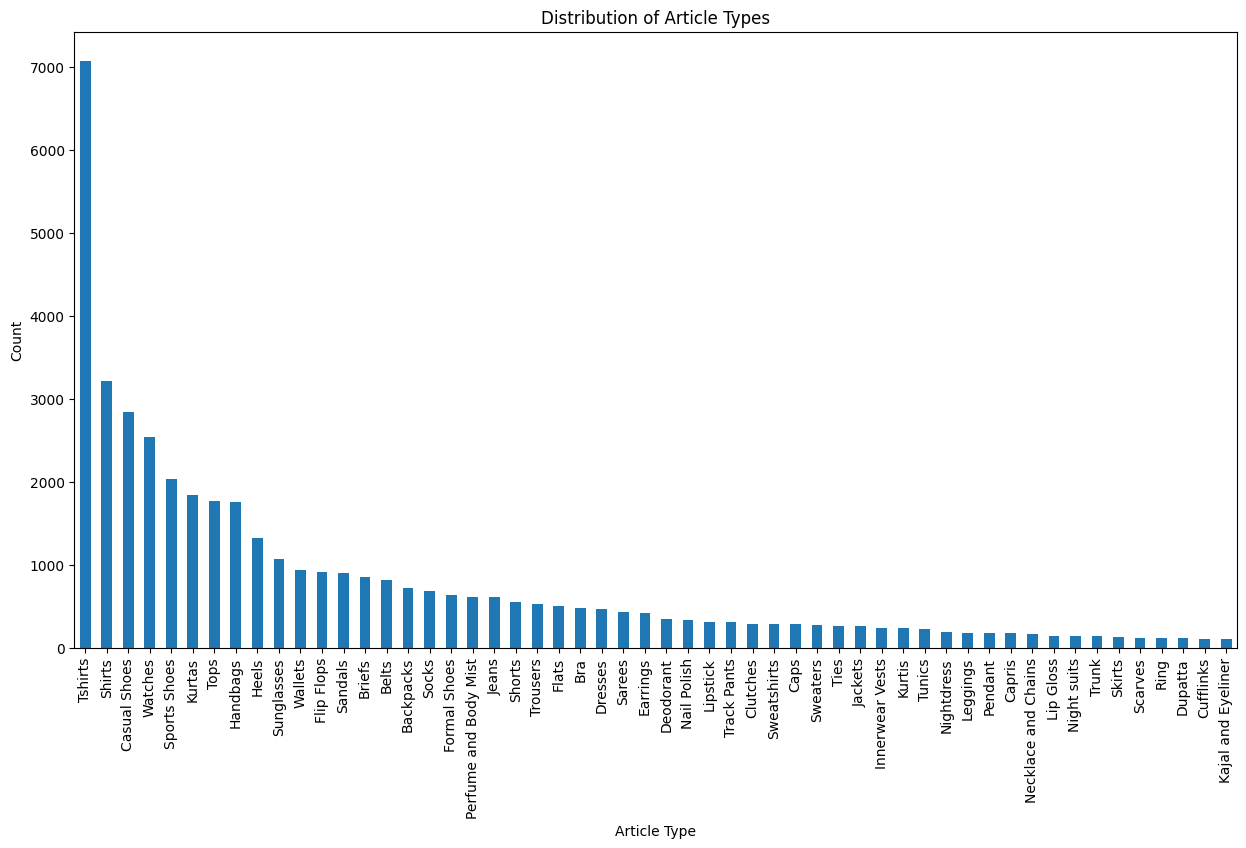

In [35]:
plt.figure(figsize=(15,8))

df['articleType'].value_counts().plot(kind='bar')

plt.title('Distribution of Article Types')
plt.ylabel('Count')
plt.xlabel('Article Type')
plt.show()

**Class Imbalance Analysis**

In [36]:
class_counts = df['articleType'].value_counts()

print("Total classes:", df['articleType'].nunique())
print("Most common class:", class_counts.max())
print("Least common class:", class_counts.min())

Total classes: 54
Most common class: 7066
Least common class: 102


**Distribution of Master Category**

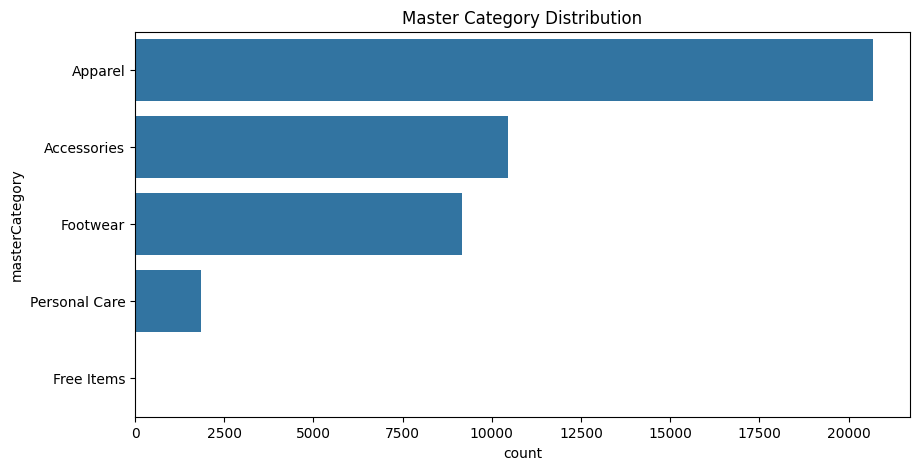

In [37]:
plt.figure(figsize=(10,5))

sns.countplot(
    y='masterCategory',
    data=df,
    order=df['masterCategory'].value_counts().index
)

plt.title("Master Category Distribution")
plt.show()

**Gender Distribution**

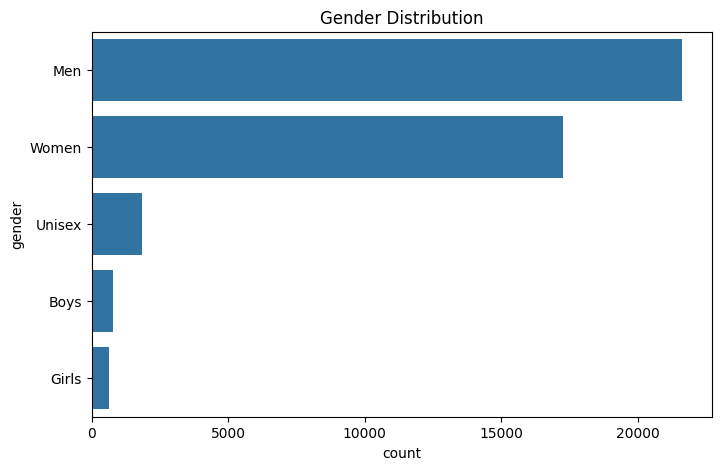

In [38]:
plt.figure(figsize=(8,5))

sns.countplot(
    y='gender',
    data=df,
    order=df['gender'].value_counts().index
)

plt.title("Gender Distribution")
plt.show()

**Usage Distribution**

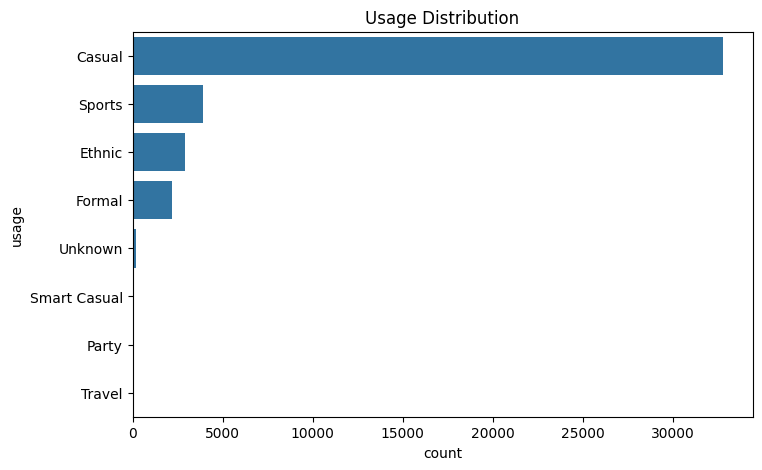

In [39]:
plt.figure(figsize=(8,5))

sns.countplot(
    y='usage',
    data=df,
    order=df['usage'].value_counts().index
)

plt.title("Usage Distribution")
plt.show()

**Season Distribution**

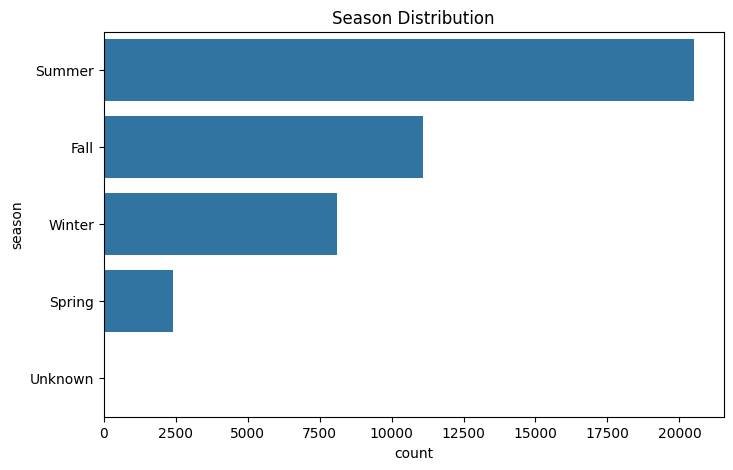

In [40]:
plt.figure(figsize=(8,5))

sns.countplot(
    y='season',
    data=df,
    order=df['season'].value_counts().index
)

plt.title("Season Distribution")
plt.show()

**Visual Inspection of Sample Images**
1. Visual inspection helped verify image quality and diversity.

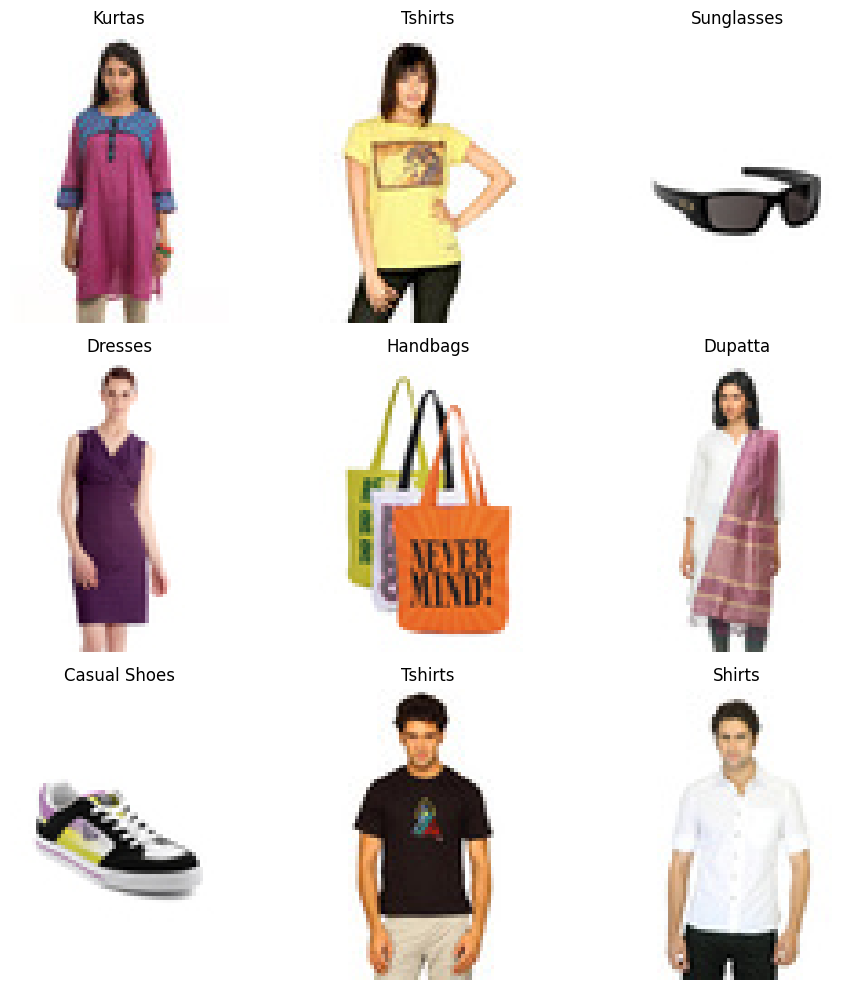

In [41]:
sample_df = df.sample(9)

plt.figure(figsize=(10,10))

for i, (_, row) in enumerate(sample_df.iterrows()):
    img_path = os.path.join(IMAGES_PATH, f"{row['id']}.jpg")
    img = mpimg.imread(img_path)

    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(row['articleType'])
    plt.axis('off')

plt.tight_layout()
plt.show()

**Image Dimension Analysis**

1. Before resizing images for deep learning, we inspected the original image dimensions.

In [42]:
from PIL import Image

widths, heights = [], []

for path in df['id'].sample(500):
    img = Image.open(f"{IMAGES_PATH}/{path}.jpg")
    widths.append(img.size[0])
    heights.append(img.size[1])

print("Average width:", np.mean(widths))
print("Average height:", np.mean(heights))

Average width: 60.0
Average height: 80.0


# Notebook 03 — Deep Learning Model Development

At this stage, we developed a Convolutional Neural Network capable of classifying ecommerce product images into the 54 articleType categories.



**Train Validation Test Split**

The dataset is divided into training, validation, and test sets. The training set is used to learn patterns from product images, the validation set is used to monitor model performance during training and tune hyperparameters, while the test set is reserved for final evaluation on unseen data.

In [48]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['label'],
    random_state=42
)

**Image Data Generators**

Image data generators are been used to load images in batches rather than loading the entire dataset into memory at once. Images are resized to a uniform size of 224×224 pixels and normalized to improve training stability. This approach allows efficient processing of thousands of ecommerce product images.

In [49]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224,224)
BATCH_SIZE = 32

train_gen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_gen = ImageDataGenerator(rescale=1./255)

test_gen = ImageDataGenerator(rescale=1./255)

**Creating Data Loaders**

In [91]:
train_data = train_gen.flow_from_dataframe(
    train_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    class_mode='raw',
    batch_size=BATCH_SIZE
)

val_data_eval = val_gen.flow_from_dataframe(
    val_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    class_mode='raw',
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 33720 validated image filenames.
Found 4215 validated image filenames.


# Building CNN Model 

A custom Convolutional Neural Network (CNN) was developed to automatically learn visual features from product images. The architecture consists of three convolutional blocks with increasing filter sizes (32, 64, and 128), followed by max-pooling layers for dimensionality reduction. The extracted feature maps are flattened and passed through a fully connected layer with dropout regularization to reduce overfitting. The output layer uses a softmax activation function to predict one of the 54 articleType classes.

In [51]:

from tensorflow.keras import layers, models

model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

**Compile Model**

1. The model is compiled by defining the optimizer, loss function, and evaluation metric. The Adam optimizer is used because it adapts learning rates efficiently, while sparse categorical cross-entropy is selected because the target labels are integer-encoded multiclass categories
2. This helps configure the learning process before training begins.

In [54]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

**Train Model**

The model is trained on the training dataset over multiple epochs (15). During each epoch, the network updates its weights to minimize classification errors. Validation performance is monitored after each epoch to track generalization and detect overfitting.

In [55]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)

Epoch 1/15


I0000 00:00:1780573292.232032     298 service.cc:152] XLA service 0x7fe98c0068a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780573292.232081     298 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780573292.232087     298 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780573292.675653     298 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-04 11:41:35.561757: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-04 11:41:35.710355: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


   2/1054 ━━━━━━━━━━━━━━━━━━━━ 53s 51ms/step - accuracy: 0.0000e+00 - loss: 5.3825  

I0000 00:00:1780573298.854420     298 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 719/1054 ━━━━━━━━━━━━━━━━━━━━ 2:17 412ms/step - accuracy: 0.3494 - loss: 2.5983

2026-06-04 11:46:36.653172: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-04 11:46:36.799864: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1054/1054 ━━━━━━━━━━━━━━━━━━━━ 537s 502ms/step - accuracy: 0.4965 - loss: 1.8266 - val_accuracy: 0.6842 - val_loss: 0.9885
Epoch 2/15
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 376s 356ms/step - accuracy: 0.6444 - loss: 1.1700 - val_accuracy: 0.7552 - val_loss: 0.7839
Epoch 3/15
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 364s 345ms/step - accuracy: 0.6951 - loss: 0.9918 - val_accuracy: 0.7805 - val_loss: 0.6876
Epoch 4/15
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 372s 353ms/step - accuracy: 0.7205 - loss: 0.8944 - val_accuracy: 0.7767 - val_loss: 0.6921
Epoch 5/15
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 389s 369ms/step - accuracy: 0.7355 - loss: 0.8360 - val_accuracy: 0.7922 - val_loss: 0.6221
Epoch 6/15
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 375s 356ms/step - accuracy: 0.7502 - loss: 0.7903 - val_accuracy: 0.7796 - val_loss: 0.6579
Epoch 7/15
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 368s 349ms/step - accuracy: 0.7613 - loss: 0.7467 - val_accuracy: 0.8081 - val_loss: 0.5860
Epoch 8/15
1054/1054 ━━━━━━━━━━━━━━━━━━━━ 367s 348ms/step - accuracy: 0.7

# CNN Training Summary (E-commerce Image Classification)

This model was trained using a custom Convolutional Neural Network (CNN) on an e-commerce product image dataset containing multiple product categories. The training process was conducted over 15 epochs using GPU acceleration.

# Training Behavior

The model demonstrated smooth and stable learning throughout the training process. Both training accuracy and validation accuracy improved consistently across epochs, while the loss steadily decreased, indicating effective optimization and convergence.

There were no signs of training instability such as sudden spikes in loss or collapsing accuracy. The model generalized well on the validation dataset, with validation performance closely tracking training performance.

# Performance Progression
Initial training accuracy started at approximately 49%, with validation accuracy around 68%
Rapid improvement was observed within the first few epochs
By mid-training (Epochs 5–10), performance stabilized around 75–82% validation accuracy
Final training phase showed minor fluctuations but overall stability

# Final Results

At the end of 15 epochs:

Final Training Accuracy: ~80%
Final Validation Accuracy: ~83%
Peak Validation Accuracy: ~84.1% (Epoch 14)
Final Loss: ~0.51

The model reached its best performance near the later epochs, after which slight fluctuations were observed, indicating convergence.

# Overall Observation

The training process reflects a well-converged CNN model with consistent improvement over time and stable generalization performance on unseen validation data.

**Save the CNN model (baseline) and Save training history**

This is done to preserve the trained CNN as a baseline reference model, allowing future comparison with improved approaches like transfer learning. It ensures the learned weights, architecture, and performance can be reused for evaluation, reproducibility, and benchmarking against newer models without retraining from scratch.

In [58]:
model.save("/kaggle/working/cnn_model.keras")

import json

with open("/kaggle/working/cnn_history.json", "w") as f:
    json.dump(history.history, f)

# Notebook 04 — Model Evaluation and Testing

**Load the Trained Model**


The saved model is loaded from storage to perform evaluation on unseen test data. This ensures that testing is conducted using the final selected model rather than a partially trained version.



1. This is done to prepare the trained model for objective performance assessment

In [77]:
from tensorflow.keras.models import load_model

model = load_model("/kaggle/working/cnn_model.keras")

print("Model loaded successfully")

Model loaded successfully


**Evaluate on validation data**

This computes the final loss and accuracy on unseen validation data.

In [78]:
loss, accuracy = model.evaluate(val_data)

print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

132/132 ━━━━━━━━━━━━━━━━━━━━ 13s 92ms/step - accuracy: 0.8311 - loss: 0.5160
Validation Loss: 0.5160
Validation Accuracy: 0.8311


**Classification Report**

Shows precision, recall, and F1-score per class.

In [92]:
import numpy as np

# predictions

y_pred = model.predict(val_data_eval)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = val_data_eval.labels



132/132 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step


In [93]:
print(len(class_names))
print(len(np.unique(y_true)))

54
54


In [94]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred_classes,
        target_names=class_names
    )
)

                       precision    recall  f1-score   support

            Backpacks       0.87      0.93      0.90        73
                Belts       0.99      0.98      0.98        81
                  Bra       0.98      0.98      0.98        47
               Briefs       0.95      0.94      0.95        85
               Capris       0.73      0.47      0.57        17
                 Caps       0.83      0.83      0.83        29
         Casual Shoes       0.80      0.64      0.71       285
             Clutches       0.71      0.59      0.64        29
            Cufflinks       1.00      0.80      0.89        10
            Deodorant       0.88      0.62      0.72        34
              Dresses       0.58      0.81      0.68        47
              Dupatta       1.00      0.50      0.67        12
             Earrings       1.00      1.00      1.00        41
                Flats       0.37      0.14      0.20        50
           Flip Flops       0.70      0.88      0.78  

**Confusion matrix**

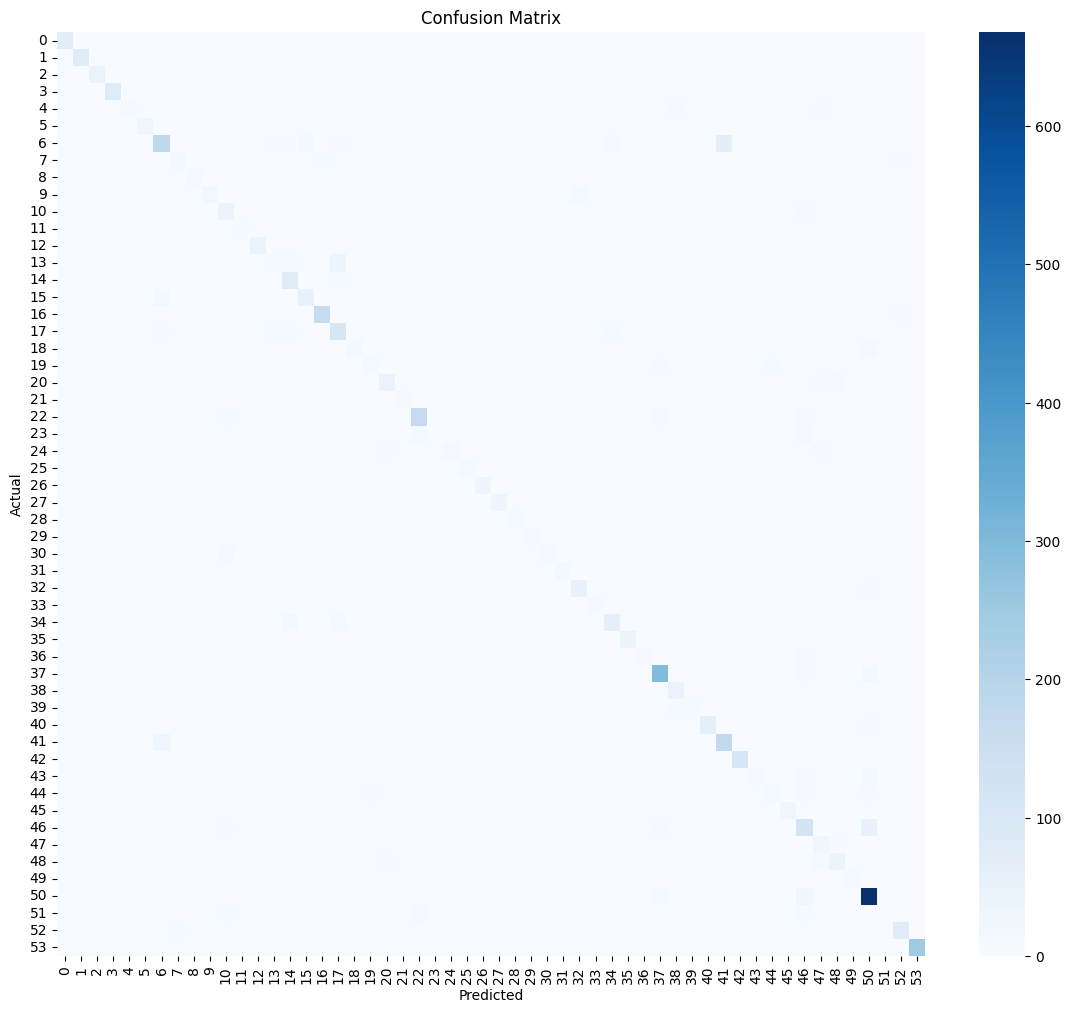

In [95]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(14,12))
sns.heatmap(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Final Evaluation Summary

The baseline Convolutional Neural Network achieved a validation accuracy of 83.11% on a 54-class e-commerce product classification task. The model demonstrated strong generalization ability, achieving a weighted F1-score of 0.82 while accurately identifying the majority of product categories. Performance was particularly strong for visually distinctive classes such as Watches, Sunglasses, Earrings, Belts, Handbags, Shirts, and Tshirts. Although some visually similar apparel categories exhibited lower performance, the overall results indicate that the CNN successfully learned meaningful product representations and provides a reliable baseline for subsequent comparison with transfer learning architectures.

# Next step: Notebook 05 - Model Deployment